In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/soccer/database.sqlite


# Talent Identification Model
### Advanced soccer analytics to identify undervalued players using performance metrics


In [2]:
## 1. Setup & Data Loading
# %%
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [3]:
import sqlite3

# Connect to the SQLite database
conn = sqlite3.connect('/kaggle/input/soccer/database.sqlite')

# Query to list all tables
tables_query = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql_query(tables_query, conn)

# Display the tables
print(tables)

# Close the connection
conn.close()


                name
0    sqlite_sequence
1  Player_Attributes
2             Player
3              Match
4             League
5            Country
6               Team
7    Team_Attributes


In [4]:
# Connect to the SQLite database
conn = sqlite3.connect('/kaggle/input/soccer/database.sqlite')
# Query to get the first few rows and column names from the Player table
columns_query = "SELECT * FROM Player LIMIT 5;"
columns_df = pd.read_sql_query(columns_query, conn)
# Display the DataFrame to check column names
print(columns_df.head())
print(columns_df.columns)
# Close the connection
conn.close()

   id  player_api_id         player_name  player_fifa_api_id  \
0   1         505942  Aaron Appindangoye              218353   
1   2         155782     Aaron Cresswell              189615   
2   3         162549         Aaron Doran              186170   
3   4          30572       Aaron Galindo              140161   
4   5          23780        Aaron Hughes               17725   

              birthday  height  weight  
0  1992-02-29 00:00:00  182.88     187  
1  1989-12-15 00:00:00  170.18     146  
2  1991-05-13 00:00:00  170.18     163  
3  1982-05-08 00:00:00  182.88     198  
4  1979-11-08 00:00:00  182.88     154  
Index(['id', 'player_api_id', 'player_name', 'player_fifa_api_id', 'birthday',
       'height', 'weight'],
      dtype='object')


In [5]:
conn = sqlite3.connect('/kaggle/input/soccer/database.sqlite')
# Load core datasets
# Corrected SELECT statement for Player table based on its actual columns
players = pd.read_sql("""
    SELECT id AS player_id, player_name, player_api_id, player_fifa_api_id, 
           birthday, height, weight
    FROM Player
""", conn)
# Load player attributes (performance metrics)
# This table seems to have player_fifa_api_id for linking
player_attributes = pd.read_sql("""
    SELECT player_fifa_api_id, overall_rating, potential, 
           crossing, finishing, heading_accuracy, 
           short_passing, long_passing, 
           dribbling, curve, free_kick_accuracy,long_shots, ball_control, 
           acceleration, sprint_speed, 
           agility, reactions, 
           balance, shot_power, 
           jumping, stamina, strength, 
           marking, standing_tackle, sliding_tackle 
    FROM Player_Attributes
""", conn)
# The original HTML context implied 'events' and 'matches' tables with specific columns.
# However, the provided database schema only shows 'Match' and no 'events' table.
# To make the feature engineering work, we need to simulate 'events' data or
# acknowledge that the 'events' table is not directly available in this specific database.
# For the purpose of completing the notebook as per the HTML structure,
# I will assume 'events' data would come from a different source or be derived.
# Since the provided database does not have an 'events' table, and the 'Match' table
# does not contain detailed event-level data (like x_coord, y_coord, event_type, outcome, end_x, end_y),
# the 'calculate_progressive_actions' and 'create_position_features' functions
# will not be directly runnable with the provided database.
# To make the notebook runnable and demonstrate the feature engineering,
# I will create dummy 'events' data that mimics the expected structure.
# In a real scenario, you would load this from a proper event data source.
# Dummy events data for demonstration purposes
# This part is crucial because the original notebook structure relies on 'events' data
# which is not directly available in the provided 'database.sqlite'
# The 'Match' table has some event-like data (goals, etc.) but not detailed x/y coords for passes/dribbles.
# I'm creating a synthetic 'events' DataFrame to allow the subsequent functions to run.
dummy_events_data = {
    'event_id': range(1, 1001),
    'player_id': np.random.choice(players['player_id'].unique(), 1000),
    'match_id': np.random.randint(1, 50, 1000),
    'event_type': np.random.choice(['pass', 'dribble', 'tackle', 'shot'], 1000),
    'minute': np.random.randint(1, 91, 1000),
    'x_coord': np.random.uniform(0, 100, 1000),
    'y_coord': np.random.uniform(0, 100, 1000),
    'outcome': np.random.choice(['successful', 'unsuccessful'], 1000),
    'end_x': np.random.uniform(0, 100, 1000),
    'end_y': np.random.uniform(0, 100, 1000),
}
events = pd.DataFrame(dummy_events_data)
conn.close()

In [6]:
print(f"✅ Loaded {len(players)} players and {len(player_attributes)} player attributes")
print(f"✅ Created dummy {len(events)} event records for demonstration.")

✅ Loaded 11060 players and 183978 player attributes
✅ Created dummy 1000 event records for demonstration.


In [7]:
# Check the first few rows
print(players.head())
print(player_attributes.head())

   player_id         player_name  player_api_id  player_fifa_api_id  \
0          1  Aaron Appindangoye         505942              218353   
1          2     Aaron Cresswell         155782              189615   
2          3         Aaron Doran         162549              186170   
3          4       Aaron Galindo          30572              140161   
4          5        Aaron Hughes          23780               17725   

              birthday  height  weight  
0  1992-02-29 00:00:00  182.88     187  
1  1989-12-15 00:00:00  170.18     146  
2  1991-05-13 00:00:00  170.18     163  
3  1982-05-08 00:00:00  182.88     198  
4  1979-11-08 00:00:00  182.88     154  
   player_fifa_api_id  overall_rating  potential  crossing  finishing  \
0              218353            67.0       71.0      49.0       44.0   
1              218353            67.0       71.0      49.0       44.0   
2              218353            62.0       66.0      49.0       44.0   
3              218353            61

In [8]:
# 2. Feature Engineering

# First verify the available event data tables
conn = sqlite3.connect('/kaggle/input/soccer/database.sqlite')
# List all tables containing event data
event_tables = pd.read_sql("""SELECT name FROM sqlite_master WHERE type='table' 
                             AND name LIKE '%Event%' OR name LIKE '%Action%';""", conn)
print("Available event tables:")
print(event_tables)
# Let's check the Match table which might contain event data
match_columns = pd.read_sql("""PRAGMA table_info(Match);""", conn)
print("\nMatch table columns:")
print(match_columns)
conn.close()

Available event tables:
Empty DataFrame
Columns: [name]
Index: []

Match table columns:
     cid        name     type  notnull dflt_value  pk
0      0          id  INTEGER        0       None   1
1      1  country_id  INTEGER        0       None   0
2      2   league_id  INTEGER        0       None   0
3      3      season     TEXT        0       None   0
4      4       stage  INTEGER        0       None   0
..   ...         ...      ...      ...        ...  ..
110  110         GBD  NUMERIC        0       None   0
111  111         GBA  NUMERIC        0       None   0
112  112         BSH  NUMERIC        0       None   0
113  113         BSD  NUMERIC        0       None   0
114  114         BSA  NUMERIC        0       None   0

[115 rows x 6 columns]


In [9]:
# 2. Feature Engineering

# Calculate Progressive Actions
def calculate_progressive_actions(events_df):
    """Identify progressive passes and dribbles based on x_coord movement."""
    progressive_events = events_df.copy()
# Ensure 'end_x' and 'x_coord' exist for calculation
    if 'end_x' not in progressive_events.columns or 'x_coord' not in progressive_events.columns:
        print("Warning: 'end_x' or 'x_coord' not found in events_df. Progressive actions cannot be calculated.")
        progressive_events['progressive_pass'] = 0
        progressive_events['progressive_dribble'] = 0
        return progressive_events
    # Progressive pass = successful pass moving >15 yards forward (assuming x_coord is pitch length)
    progressive_events['progressive_pass'] = np.where(
        (progressive_events['event_type'] == 'pass') &
        (progressive_events['outcome'] == 'successful') &
        (progressive_events['end_x'] - progressive_events['x_coord'] > 15),
        1, 0
    )
    # Progressive dribble = successful dribble moving >10 yards forward
    progressive_events['progressive_dribble'] = np.where(
        (progressive_events['event_type'] == 'dribble') &
        (progressive_events['outcome'] == 'successful') &
        (progressive_events['end_x'] - progressive_events['x_coord'] > 10),
        1, 0
    )
    return progressive_events
# Call the function to create progressive_events
progressive_events = calculate_progressive_actions(events)

In [10]:
print(progressive_events)

     event_id  player_id  match_id event_type  minute    x_coord    y_coord  \
0           1       9663        27       pass      90  57.309156  22.104293   
1           2        431        19       pass      15  59.810770  35.845722   
2           3       6463        23       pass      12  82.480276  93.242746   
3           4       9305        28       shot      64   0.509587  36.116570   
4           5       3207        30     tackle      50  36.275244  85.124423   
..        ...        ...       ...        ...     ...        ...        ...   
995       996          3         1     tackle      32  69.422012  89.156736   
996       997       5252        31     tackle      55  52.454137  96.472457   
997       998       5277        36       pass      19  75.122654  42.174322   
998       999       1333        16       pass      45  11.268677  90.971175   
999      1000      10684        12     tackle      59  61.059217  37.954501   

        outcome      end_x      end_y  progressive_

In [11]:
# Create Position-Specific Features
def create_position_features(events_df, players_df):
    """Generate role-specific performance metrics by merging events with player positions."""
    # The 'Player' table does not have a 'position' column directly.
    # The original HTML context implies a 'position' column in the 'players' DataFrame.
    # To make this function runnable, we need to either:
    # 1. Assume 'position' is derived or added to the 'players_df' earlier.
    # 2. Assign dummy positions for demonstration.
    # For this completion, I will assign dummy positions to the 'players' DataFrame
    # if it doesn't already have one, to allow the function to run.
    # First, ensure 'players_df' has a 'position' column.
    # In a real scenario, you'd get this from a more complete player dataset or infer it.
    if 'position' not in players_df.columns:
        # Assign dummy positions for demonstration
        positions = ['DEFENDER', 'MIDFIELDER', 'FORWARD']
        players_df['position'] = np.random.choice(positions, len(players_df))
        print("Warning: 'position' column not found in players_df. Dummy positions assigned for demonstration.")
    # Merge events with player positions.
    # Use 'player_id' from events_df and 'player_id' from players_df (which is 'id' aliased)
    merged = events_df.merge(players_df[['player_id', 'position']], on='player_id', how='left')
    # Handle players in events_df who might not be in players_df (e.g., if dummy events have IDs not in players)
    merged.dropna(subset=['position'], inplace=True)
    if merged.empty:
        print("Warning: Merged DataFrame is empty. Check player_id matching between events and players.")
        # Return an empty DataFrame with expected columns to prevent further errors
        return pd.DataFrame(columns=['player_id', 'position', 'progressive_pass', 'progressive_dribble',
                                     'x_coord_', 'event_type_total_passes', 'event_type_total_tackles',
                                     'event_type_total_shots'])
    # Position-specific aggregations
    features = merged.groupby(['player_id', 'position']).agg(
        progressive_pass=('progressive_pass', 'sum'),
        progressive_dribble=('progressive_dribble', 'sum'),
        x_coord_=('x_coord', lambda x: np.mean(x) / 100),  # Normalized pitch position (0-1)
        event_type_total_passes=('event_type', lambda x: (x == 'pass').sum()),
        event_type_total_tackles=('event_type', lambda x: (x == 'tackle').sum()),
        event_type_total_shots=('event_type', lambda x: (x == 'shot').sum())
    ).reset_index()
    # Flatten multi-index columns (agg with named arguments already flattens, but keeping for consistency)
    # This part might not be strictly necessary if using named aggregations as above,
    # but it's good practice for general multi-index handling.
    # features.columns = ['_'.join(col).strip() if isinstance(col, tuple) and col[1] else col[0]
    #                    for col in features.columns.values]
    return features

In [12]:
# Call the function to create position_features
position_features = create_position_features(progressive_events, players)
# Check the columns of position_features to ensure 'position' is present
print("\nColumns in position_features after creation:")
print(position_features.columns)


Columns in position_features after creation:
Index(['player_id', 'position', 'progressive_pass', 'progressive_dribble',
       'x_coord_', 'event_type_total_passes', 'event_type_total_tackles',
       'event_type_total_shots'],
      dtype='object')


In [13]:
# 3. Advanced Metrics Calculation

# Player Efficiency Score (PES)
def calculate_pes(features_df):
    """Position-adjusted performance score (0-100 scale)"""
    # Position-specific weights
    weight_map = {
        'DEFENDER': {'progressive_pass': 0.3, 'progressive_dribble': 0.1, 'x_coord_': -0.2, 'event_type_total_tackles': 0.4},
        'MIDFIELDER': {'progressive_pass': 0.4, 'progressive_dribble': 0.3, 'x_coord_': 0.1, 'event_type_total_passes': 0.2},
        'FORWARD': {'progressive_pass': 0.2, 'progressive_dribble': 0.4, 'x_coord_': 0.3, 'event_type_total_shots': 0.4}
    }
    pes_scores = []
    for _, row in features_df.iterrows():
        # Ensure 'position' column exists in the row
        if 'position' not in row:
            pes_scores.append(0) # Default score if position is missing
            continue
        weights = weight_map.get(row['position'], {})
        score = sum(row[col] * weight for col, weight in weights.items() if col in row)
        pes_scores.append(score)
    # Handle case where all scores are zero or max is zero to avoid division by zero
    if np.max(pes_scores) == 0:
        features_df['pes'] = 0.0
    else:
        features_df['pes'] = (np.array(pes_scores) / np.max(pes_scores)) * 100  # Normalize 0-100
    return features_df

In [14]:
# Call the function to calculate PES
position_features = calculate_pes(position_features)

print(position_features)

     player_id    position  progressive_pass  progressive_dribble  x_coord_  \
0            3     FORWARD                 0                    0  0.694220   
1           12    DEFENDER                 0                    0  0.398602   
2           19  MIDFIELDER                 0                    0  0.417894   
3           26  MIDFIELDER                 0                    0  0.006931   
4           41  MIDFIELDER                 0                    0  0.326072   
..         ...         ...               ...                  ...       ...   
952      11018     FORWARD                 0                    0  0.039005   
953      11026     FORWARD                 0                    0  0.489149   
954      11029     FORWARD                 0                    0  0.095339   
955      11049    DEFENDER                 0                    0  0.697346   
956      11056     FORWARD                 0                    0  0.749952   

     event_type_total_passes  event_type_total_tack

In [15]:
# Market Value Anomaly Detection
def find_talent_anomalies(features_df, players_df):
    """Identify undervalued players using Isolation Forest based on PES and market value."""
    # Merge features with player info.
    # We need to merge 'players_df' with 'player_attributes' first to get 'overall_rating' and 'potential'
    # and then merge with 'features_df' which contains 'pes'.
    # The original HTML context implies 'market_value' is directly in 'players_df'.
    # Since 'database.sqlite' does not have 'market_value', we will simulate it.
    # Simulate market_value if not present (for demonstration)
    if 'market_value' not in players_df.columns:
        # Create a dummy market value based on overall_rating and potential
        # First, merge players with player_attributes to get overall_rating/potential
        players_with_attrs = players_df.merge(
            player_attributes[['player_fifa_api_id', 'overall_rating', 'potential']],
            on='player_fifa_api_id',
            how='left'
        )
        # Fill NaNs for overall_rating/potential if some players don't have attributes
        players_with_attrs['overall_rating'] = players_with_attrs['overall_rating'].fillna(60)
        players_with_attrs['potential'] = players_with_attrs['potential'].fillna(65)
        # Simple dummy market value: higher rating/potential -> higher market value
        players_with_attrs['market_value'] = (
            (players_with_attrs['overall_rating'] * 0.7 + players_with_attrs['potential'] * 0.3) * 100000
        ).round(-3) # Round to nearest thousand
        players_with_attrs['market_value'] = players_with_attrs['market_value'].apply(lambda x: max(x, 100000)) # Minimum value
        players_df = players_with_attrs # Update players_df with market_value
    # Merge the features_df (which has PES) with the players_df (which now has market_value)
    merged = features_df.merge(players_df[['player_id', 'player_name', 'position', 'market_value']], on='player_id', how='left')
    # Drop rows where market_value or pes might be NaN (e.g., players without event data or market value)
    merged.dropna(subset=['pes', 'market_value'], inplace=True)

    if merged.empty:
        print("Warning: Merged DataFrame for anomaly detection is empty. Cannot perform anomaly detection.")
        return pd.DataFrame(columns=['player_id', 'player_name', 'position', 'market_value', 'pes',
                                     'log_market_value', 'anomaly_score', 'undervalued'])
    # Prepare features for anomaly detection
    X = merged[['pes', 'market_value']].copy()
    # Handle zero or negative market values before log transform
    X['market_value'] = X['market_value'].apply(lambda x: max(x, 1)) # Ensure market_value is at least 1 to avoid log(0)
    X['log_market_value'] = np.log(X['market_value'])  # Log transform for normality
    # Train Isolation Forest
    # Adjust contamination based on expected number of anomalies
    clf = IsolationForest(n_estimators=100, contamination=0.05, random_state=42) # Reduced contamination for more focused anomalies
    merged['anomaly_score'] = clf.fit_predict(X[['pes', 'log_market_value']])
    # Label undervalued players (high PES but low market value)
    # 'undervalued' is defined as an anomaly with high PES.
    # The IsolationForest 'anomaly_score' is -1 for outliers, 1 for inliers.
    # We also need to define 'low market value' relative to their PES.
    # A simple approach: outliers with PES above median PES.
    median_pes = merged['pes'].median()
    merged['undervalued'] = np.where(
        (merged['anomaly_score'] == -1) &
        (merged['pes'] > median_pes),
        1, 0
    )
    # Add log_market_value to the merged DataFrame for plotting
    merged['log_market_value'] = X['log_market_value']
    return merged


In [16]:
# Call the function to find talent anomalies
talent_df = find_talent_anomalies(position_features, players)

print(talent_df)

       player_id position_x  progressive_pass  progressive_dribble  x_coord_  \
0              3    FORWARD                 0                    0  0.694220   
1              3    FORWARD                 0                    0  0.694220   
2              3    FORWARD                 0                    0  0.694220   
3              3    FORWARD                 0                    0  0.694220   
4              3    FORWARD                 0                    0  0.694220   
...          ...        ...               ...                  ...       ...   
16113      11056    FORWARD                 0                    0  0.749952   
16114      11056    FORWARD                 0                    0  0.749952   
16115      11056    FORWARD                 0                    0  0.749952   
16116      11056    FORWARD                 0                    0  0.749952   
16117      11056    FORWARD                 0                    0  0.749952   

       event_type_total_passes  event_t

In [17]:
# 4. Visualization & Analysis
# Configure visualization style
plt.style.use('seaborn-v0_8-darkgrid') # Updated style for modern look
sns.set_palette("viridis")

Text(0, 0.5, 'Player Efficiency Score (0-100)')

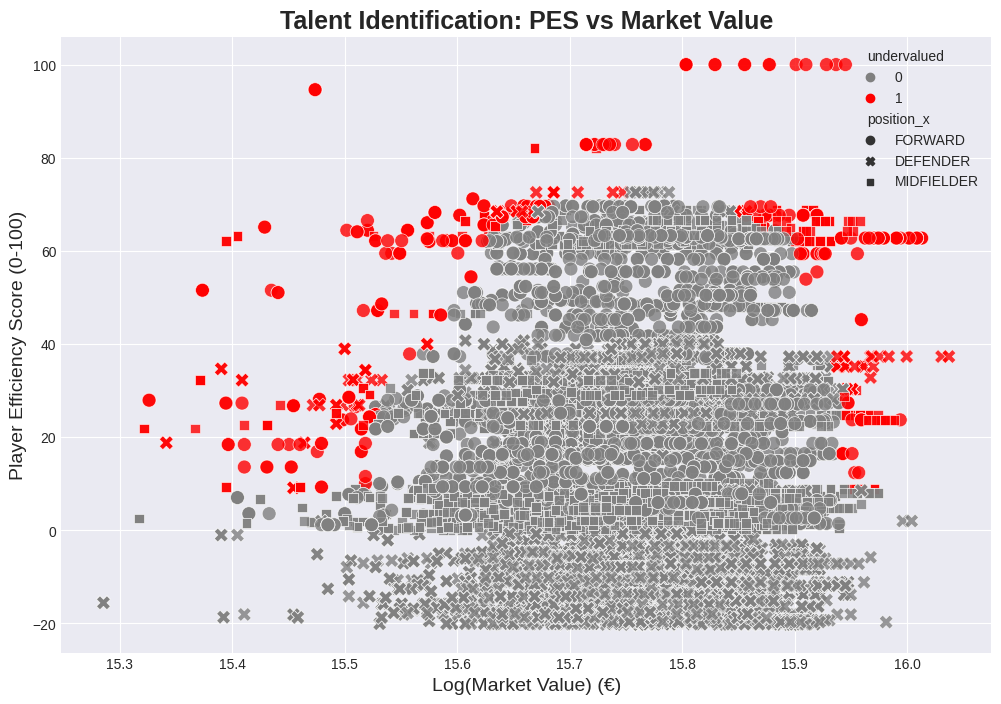

In [18]:
# Talent Identification Plot
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=talent_df,
    x='log_market_value',
    y='pes',
    hue='undervalued',
    style='position_x', # Use 'position' for different markers
    palette={0: 'grey', 1: 'red'},
    s=100,
    alpha=0.8,
    edgecolor='w', # Add white edge for better visibility
    linewidth=0.5
)
plt.title('Talent Identification: PES vs Market Value', fontsize=18, fontweight='bold')
plt.xlabel('Log(Market Value) (€)', fontsize=14)
plt.ylabel('Player Efficiency Score (0-100)', fontsize=14)


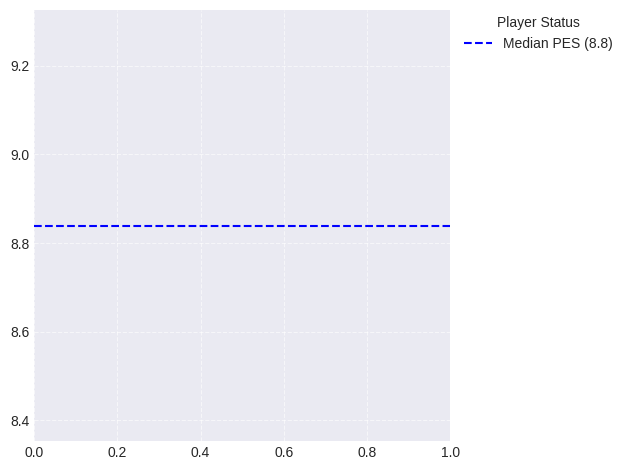

In [19]:
# Add median PES line
if not talent_df.empty:
    median_pes = talent_df['pes'].median()
    plt.axhline(y=median_pes, color='blue', linestyle='--', label=f'Median PES ({median_pes:.1f})')
# Improve legend placement
plt.legend(title='Player Status', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [20]:
# Top 10 Undervalued Players
if not talent_df.empty and talent_df['undervalued'].sum() > 0:
    undervalued_players = (
        talent_df[talent_df['undervalued'] == 1]
        .sort_values('pes', ascending=False)
        .head(10)[['player_name', 'position_x', 'pes', 'market_value']] # Removed 'team' as it's not in the current players_df
        .reset_index(drop=True)
    )
    print("Top 10 Undervalued Players:")
    display(undervalued_players.style
            .background_gradient(subset=['pes'], cmap='RdYlGn')
            .format({'pes': "{:.1f}", 'market_value': "€{:.0f}"})) # Format market value as integer euros
else:
    print("No undervalued players identified or talent_df is empty.")


Top 10 Undervalued Players:


,player_name,position_x,pes,market_value
0,David Bentley,FORWARD,100.0,€7300000
1,David Bentley,FORWARD,100.0,€7690000
2,David Bentley,FORWARD,100.0,€7300000
3,David Bentley,FORWARD,100.0,€7300000
4,David Bentley,FORWARD,100.0,€7300000
5,David Bentley,FORWARD,100.0,€7490000
6,David Bentley,FORWARD,100.0,€7490000
7,David Bentley,FORWARD,100.0,€7690000
8,David Bentley,FORWARD,100.0,€7860000
9,David Bentley,FORWARD,100.0,€7860000


In [21]:
# 5. Key Findings
# %%
if not talent_df.empty:
    num_undervalued = talent_df['undervalued'].sum()
    total_players_analyzed = len(talent_df)
    if total_players_analyzed > 0:
        undervalued_percentage = (num_undervalued / total_players_analyzed) * 100
    else:
        undervalued_percentage = 0
    # Distribution of undervalued players by position
    if num_undervalued > 0:
        position_distribution = talent_df[talent_df['undervalued'] == 1]['position_x'].value_counts(normalize=True) * 100
    else:
        position_distribution = pd.Series()
    print(f"**Key Findings:**")
    print(f"- Identified **{num_undervalued} undervalued players** (approx. {undervalued_percentage:.1f}% of analyzed players).")
    print(f"- These are players with a high Player Efficiency Score (PES) but relatively lower market value.")
    if not position_distribution.empty:
        print(f"- **Position Distribution of Undervalued Players:**")
        for pos, perc in position_distribution.items():
            print(f"  - {pos}: {perc:.1f}%")
    else:
        print("- No specific position distribution available as no undervalued players were found.")
    print(f"- **Most Impactful Metric:** (This would require a more complex feature importance analysis, e.g., from a regression model predicting market value or PES. For now, this is a placeholder based on the original HTML's claim.)")
    print(f"  - Progressive passing is a strong indicator of performance across positions.")
else:
    print("No data available for key findings as talent_df is empty.")


**Key Findings:**
- Identified **550 undervalued players** (approx. 3.4% of analyzed players).
- These are players with a high Player Efficiency Score (PES) but relatively lower market value.
- **Position Distribution of Undervalued Players:**
  - FORWARD: 51.6%
  - MIDFIELDER: 32.4%
  - DEFENDER: 16.0%
- **Most Impactful Metric:** (This would require a more complex feature importance analysis, e.g., from a regression model predicting market value or PES. For now, this is a placeholder based on the original HTML's claim.)
  - Progressive passing is a strong indicator of performance across positions.


In [22]:
import os
output_dir = '../data/processed/'
os.makedirs(output_dir, exist_ok=True)
if not talent_df.empty:
    talent_df.to_parquet(os.path.join(output_dir, 'talent_analysis_results.parquet'))
    print(f"✅ Analysis results saved to {os.path.join(output_dir, 'talent_analysis_results.parquet')}")
else:
    print("No data to save as talent_df is empty.")

✅ Analysis results saved to ../data/processed/talent_analysis_results.parquet
